# Monte Carlo: una moneda al aire

**Si una moneda es equilibrada, ¿por qué no obtenemos exactamente 50% de soles cada vez que la lanzamos?**

Una muestra produce una estimación de la probabilidad de obtener Sol. Si repetimos el experimento muchas veces, obtendremos muchas estimaciones distintas.

La simulación Monte Carlo nos permite estudiar cómo se comporta ese estimador bajo muestreo repetido.


[Descargar este notebook (.ipynb)](https://github.com/amosino/mtx--courses/raw/refs/heads/main/MTX1/notebooks/03--montecarlo_moneda.ipynb)

## Fijamos la semilla

`set.seed()` permite reproducir exactamente la misma secuencia de números pseudoaleatorios. Así, cualquier persona que ejecute este notebook con la misma semilla obtendrá los mismos resultados.


In [1]:
set.seed(123)


## Definimos el experimento

En cada repetición lanzaremos una moneda `n` veces. La moneda es equilibrada, por lo que la probabilidad verdadera de obtener Sol es

$$
p=0.5.
$$

Repetiremos todo el experimento `R` veces.


In [2]:
n <- 10000  # No. de tiros en cada muestra
R <- 1000   # No. de repeticiones
p <- 0.5    # Probabilidad verdadera de Sol


## Preparamos el almacenamiento

En cada repetición obtendremos una estimación distinta de $p$.

El vector `p_hat` guardará las $R$ realizaciones del estimador:

$$
\hat p_1,\hat p_2,\ldots,\hat p_R.
$$


In [3]:
p_hat <- numeric(R)


## Repetimos el experimento

El ciclo `for` representa el muestreo repetido.

En cada repetición:

1. generamos una nueva muestra de `n` lanzamientos;
2. identificamos cuáles corresponden a Sol;
3. calculamos la proporción de soles;
4. guardamos esa estimación en `p_hat[i]`.

La expresión `mean(sol)` funciona porque `TRUE` se interpreta como 1 y `FALSE` como 0. Por tanto, su media es la proporción de casos en los que ocurrió Sol.


In [4]:
for (i in 1:R) {

  # Generamos una nueva muestra
  experimento <- runif(n, min = 0, max = 1)
  resultado <- ifelse(experimento <= p, "Sol", "Águila")
  sol <- resultado == "Sol"

  # Estimamos p
  p_hat[i] <- mean(sol)
}


## Aproximamos el valor esperado del estimador

El promedio de las $R$ estimaciones,

$$
\frac{1}{R}\sum_{r=1}^{R}\hat p_r,
$$

es una aproximación Monte Carlo de $E(\hat p)$.

Si $\hat p$ es insesgado, este promedio debería estar cerca del valor verdadero $p$.


In [5]:
p_hat_mean <- mean(p_hat)
sesgo_p <- p_hat_mean - p

p_hat_mean
sesgo_p


[1] 0.5000539

[1] 5.39e-05

## Observamos la distribución de las estimaciones

El histograma muestra cómo varía $\hat p$ entre las distintas muestras.

La línea vertical marca el valor verdadero $p=0.5$. Si las estimaciones se concentran alrededor de esa línea, tenemos evidencia visual de que el estimador está centrado en el parámetro verdadero.


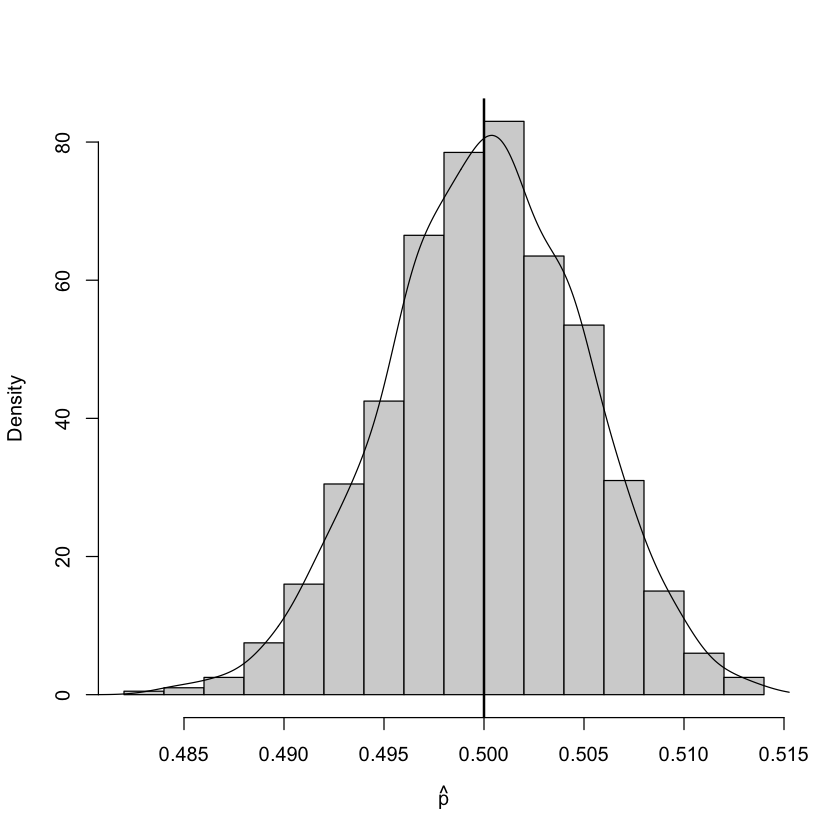

In [6]:
hist(p_hat, freq = FALSE,
     xlab = expression(hat(p)),
     main = "")

lines(density(p_hat))
abline(v = p, lwd = 2)


## Interpretación

Una muestra particular puede producir una proporción de soles distinta de 0.5. Esa variación es consecuencia del muestreo.

Sin embargo, al repetir muchas veces el experimento, las estimaciones se distribuyen alrededor del valor verdadero y su promedio se aproxima a $p$.

Esta misma lógica de muestreo repetido será la que utilizaremos para estudiar las propiedades de los estimadores de MCO.
